# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [1]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [2]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')

print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [3]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [4]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [6]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [7]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94
Explained by: Generosity,1097,51.84
Explained by: Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2016–2026.

In [ ]:
df_whr.rename(columns={'Life evaluation (3-year average)': 'life_ladder'}, inplace=True)

In [9]:
# f. Filter data Indonesia 2006–2023
df_idn = df_whr[
    (df_whr['Country name'] == 'Indonesia') &
    (df_whr['Year'].between(2021, 2026))
].reset_index(drop=True)

print(f'Jumlah baris df_idn: {len(df_idn)}')
display(df_idn)

Jumlah baris df_idn: 5


,Year,Rank,Country name,life_ladder,Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020
1,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
2,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
3,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
4,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** :  adalah data yang berbentuk kategorik atau deskripsi, atau kata-kata 
  - Nominal  :  Country Name.
  - Ordinal  :  -
- **Kuantitatif** :  adalah data yang berbentuk numerik dapat di ukur secara statistik.
  - Diskrit  : Year, Rank, Life evaluation (3-year average), Lower whisker, Lower whisker, Explained by: Log GDP per capita	1097, Explained by: Social  support, Explained by: Healthy life expectancy, Explained by: Freedom to make life choices, Explained by: Generosity, Explained by: Perceptions of corruption, Dystopia + residual.
  - Kontinu  :  -

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [10]:
# b & c. Tabel klasifikasi variabel
klasifikasi = pd.DataFrame({
    'nama_kolom'    : df_idn.columns.tolist(),
    'tipe_variabel' : [
        # Isi tipe untuk setiap kolom, contoh: 'Kualitatif - Nominal'
        'Kuantitatif - Diskrit',   # Country name
        'Kuantitatif - Diskrit',  # year
        'Kualititatif - Nominal',    #rank
        'Kuantitattif- Kontinu',
        'Kuantitatif - Kontinu',                    # Life Ladder
        'Kuantitatif - Kontinu',                    # Log GDP per capita
        'Kuantitatif - Kontinu',                    # Social support
        'Kuantitatif - Kontinu',                    # Healthy life expectancy at birth
        'Kuantitatif - Kontinu',                    # Freedom to make life choices
        'Kuantitatif - Kontinu',                    # Generosity
        'Kuantitatif - Kontinu',                    # Perceptions of corruption
        'Kuantitatif - Kontinu',                    # Positive affect
        'Kuantitatif - Kontinu',                    # Negative affect
    ],
    'alasan' : [
        # Isi alasan singkat untuk setiap kolom
        'Tahun adalah bilangan bulat yang bisa dihitung',
        'Rank adalah bilangan bulat yang bisa dihitung',
        'Nama negara bersifat kategorik tanpa urutan',
        'Life Ladder bersifat rasio dan berupa bilangan desimal',
        'Lower Whisker per capita bersifat rasio dan berupa bilangan desimal',
        'Upper Whisker per capita bersifat rasio dan berupa bilangan desimal',
        'Log GDP per capita bersifat rasio dan berupa bilangan desimal',
        'Social support bersifat rasio dan berupa bilangan desimal',
        'Healthy life expectancy at birth bersifat rasio dan berupa bilangan desimal',
        'Freedom to make life choices bersifat rasio dan berupa bilangan desimal',
        'Generosity bersifat rasio dan berupa bilangan desimal',
        'Perceptions of corruption bersifat rasio dan berupa bilangan desimal',
        'Dystopia + residual bersifat rasio dan berupa bilangan desimal',
    ]
})
display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,Year,Kuantitatif - Diskrit,Tahun adalah bilangan bulat yang bisa dihitung
1,Rank,Kuantitatif - Diskrit,Rank adalah bilangan bulat yang bisa dihitung
2,Country name,Kualititatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,life_ladder,Kuantitattif- Kontinu,Life Ladder bersifat rasio dan berupa bilangan...
4,Lower whisker,Kuantitatif - Kontinu,Lower Whisker per capita bersifat rasio dan be...
5,Upper whisker,Kuantitatif - Kontinu,Upper Whisker per capita bersifat rasio dan be...
6,Explained by: Log GDP per capita,Kuantitatif - Kontinu,Log GDP per capita bersifat rasio dan berupa b...
7,Explained by: Social support,Kuantitatif - Kontinu,Social support bersifat rasio dan berupa bilan...
8,Explained by: Healthy life expectancy,Kuantitatif - Kontinu,Healthy life expectancy at birth bersifat rasi...
9,Explained by: Freedom to make life choices,Kuantitatif - Kontinu,Freedom to make life choices bersifat rasio da...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

Menentukan Jenis Uji Statistik yang Tepat, Mencegah Kesalahan Interpretasi Data, Menentukan Metode Visualisasi Data, Mengidentifikasi Peran Variabel dalam Model

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [11]:
# a. Central Tendency — Life Ladder
col = df_whr["life_ladder"] # Ganti df menjadi df_whr

mean_ll   = col.mean()
median_ll = col.median()
mode_ll   = col.mode()[0]


print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')

# 1 # a. Central Tendency - Life Ladder


Mean   Life Ladder : 5.4657
Median Life Ladder : 5.4800
Mode   Life Ladder : 5.4770


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> Mean karena Distribusi Data Sempurna, tidak ada kecondongan ekstrem ke kanan maupun ke kiri. Karena distribusinya normal

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [12]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Year,2023.0000,2023.000,2021.000
Rank,84.2000,84.000,87.000
life_ladder,5.4638,5.568,5.617
Lower whisker,5.3598,5.466,5.139
Upper whisker,5.5676,5.670,5.341
Explained by: Log GDP per capita,1.3854,1.382,1.288
Explained by: Social support,1.1674,1.184,0.883
Explained by: Healthy life expectancy,0.4528,0.472,0.314
Explained by: Freedom to make life choices,0.8046,0.779,0.620
Explained by: Generosity,0.3814,0.399,0.295


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

In [13]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby('Year')['life_ladder'].mean().rename('Global Mean')
global_filtered = df_whr[df_whr['Country name'] == 'Indonesia']
idn_series = global_filtered.set_index('Year')['life_ladder'].rename('Indonesia')

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi

,Indonesia,Global Mean,Selisih
Year,,,
2025,5.6170,5.6499,-0.0329
2024,5.6170,5.5782,0.0388
2023,5.5680,5.5276,0.0404
2022,5.2770,5.5398,-0.2628
2021,5.2400,5.5536,-0.3136
2020,5.3450,5.5328,-0.1878
2019,5.2856,5.4732,-0.1876
2018,5.1920,5.4071,-0.2151
2017,5.0930,5.3759,-0.2829


✏️ *Interpretasi perbandingan Indonesia vs global:*

> Life ladder indonesia dalam 5tahun terakhir hampir selalu mengalami kenaikan, hanya di tahun 2024 yang tidak mengalami kenaikan masih sama dengan tahun 2024, di bandingkan dengan global life ladder indonesia masih lebih rendah nilainya, di tahun 2023 dan 2024 life ladder imdonesia lebih tinggi dari pada global.

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [14]:
# a. Ukuran dispersi — Life Ladder
col = 'life_ladder'
data = df_idn[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
std = data.std()

dispersi = {
    'Range'                     : data.max() - data.min(),
    'Variance'                  : data.var(),
    'Standard Deviation'        : std,
    'IQR (Q3 - Q1)'             : iqr,
    'Coefficient of Variation'  : std / data.mean(),
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.3770
Variance                      : 0.0357
Standard Deviation            : 0.1889
IQR (Q3 - Q1)                 : 0.3400
Coefficient of Variation      : 0.0346


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*

> Jawaban Anda di sini...

In [15]:
# c. Std Dev Indonesia vs global
std_idn    = df_idn["life_ladder"].std()
std_global = df_whr["life_ladder"].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1889
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [18]:
# d. IQR semua kolom numerik
iqr_all = df_whr.quantile(0.75, numeric_only=True) - df_whr.quantile(0.25, numeric_only=True)

iqr_df = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

,IQR
Rank,76.0000
Year,7.0000
life_ladder,1.7165
Lower whisker,1.6704
Upper whisker,1.6188
Dystopia + residual,0.8730
Explained by: Log GDP per capita,0.6920
Explained by: Social support,0.5170
Explained by: Healthy life expectancy,0.3226
Explained by: Freedom to make life choices,0.2640


In [19]:
# d. IQR semua kolom numerik
iqr_all = df_whr.quantile(0.75, numeric_only=True) - df_whr.quantile(0.25, numeric_only=True)

iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)

,IQR
Rank,76.0000
Year,7.0000
life_ladder,1.7165
Lower whisker,1.6704
Upper whisker,1.6188
Dystopia + residual,0.8730
Explained by: Log GDP per capita,0.6920
Explained by: Social support,0.5170
Explained by: Healthy life expectancy,0.3226
Explained by: Freedom to make life choices,0.2640


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [20]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Year,0.08
Upper whisker,3.33
life_ladder,3.46
Rank,3.50
Lower whisker,3.60
Explained by: Log GDP per capita,5.83
Dystopia + residual,9.99
Explained by: Social support,15.25
Explained by: Healthy life expectancy,18.51
Explained by: Generosity,18.69


✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

Kolom paling stabil berdasarkan CV adalah Year, karena memiliki nilai CV paling kecil (0.08%), yang menunjukkan tingkat variasi atau sebaran data paling rendah relatif terhadap nilai rata-ratanya

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [ ]:
# a. Deteksi outlier — metode IQR
col  ='life_ladder'
data = df_whr[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_iqr = df_whr[(data < lower) | (data > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['Year', col]])

Batas bawah IQR : 2.0300
Batas atas  IQR : 8.8960
Jumlah outlier  : 4


,Year,life_ladder
146,2025,1.446
293,2024,1.364
436,2023,1.721
573,2022,1.859


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [27]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['Year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,Year,life_ladder



Perbandingan:
  IQR    : 4 outlier
  Z-Score: 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

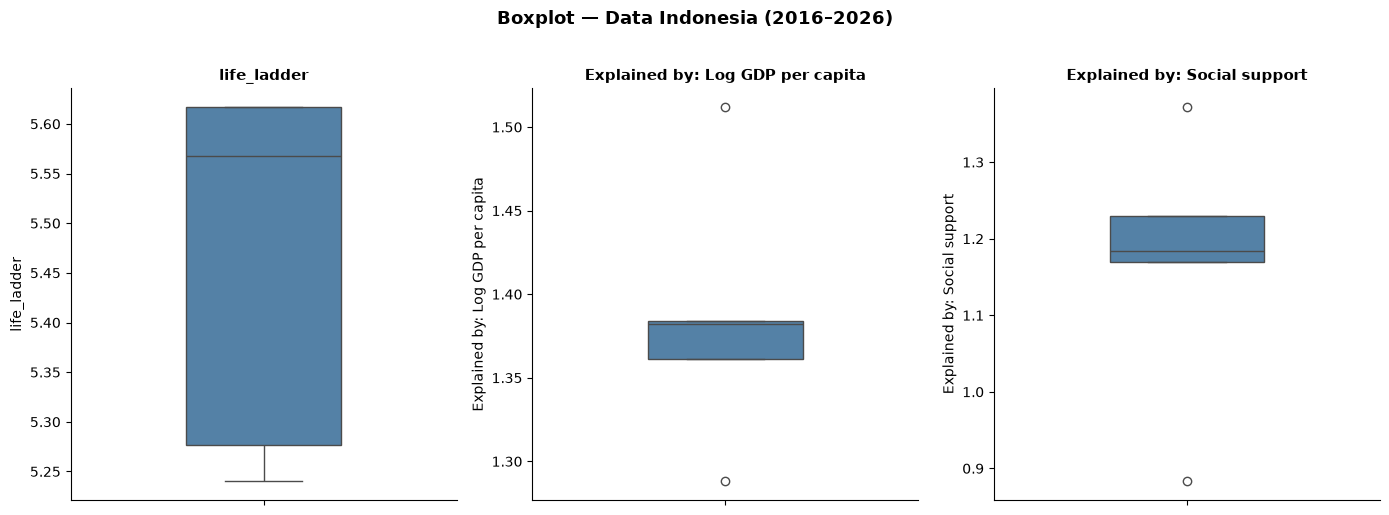

In [33]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['life_ladder', 'Explained by: Log GDP per capita', 'Explained by: Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2016–2026)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

>life_ladder: Tidak terdapat outlier.
> Log GDP per capita: Terdapat 2 outlier, yaitu satu titik ekstrem di bagian nilai terendah dan satu titik di bagian nilai tertinggi.
> Social support: Terdapat 2 outlier, yaitu satu titik ekstrem di bagian nilai terendah dan satu titik di bagian nilai tertinggi.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

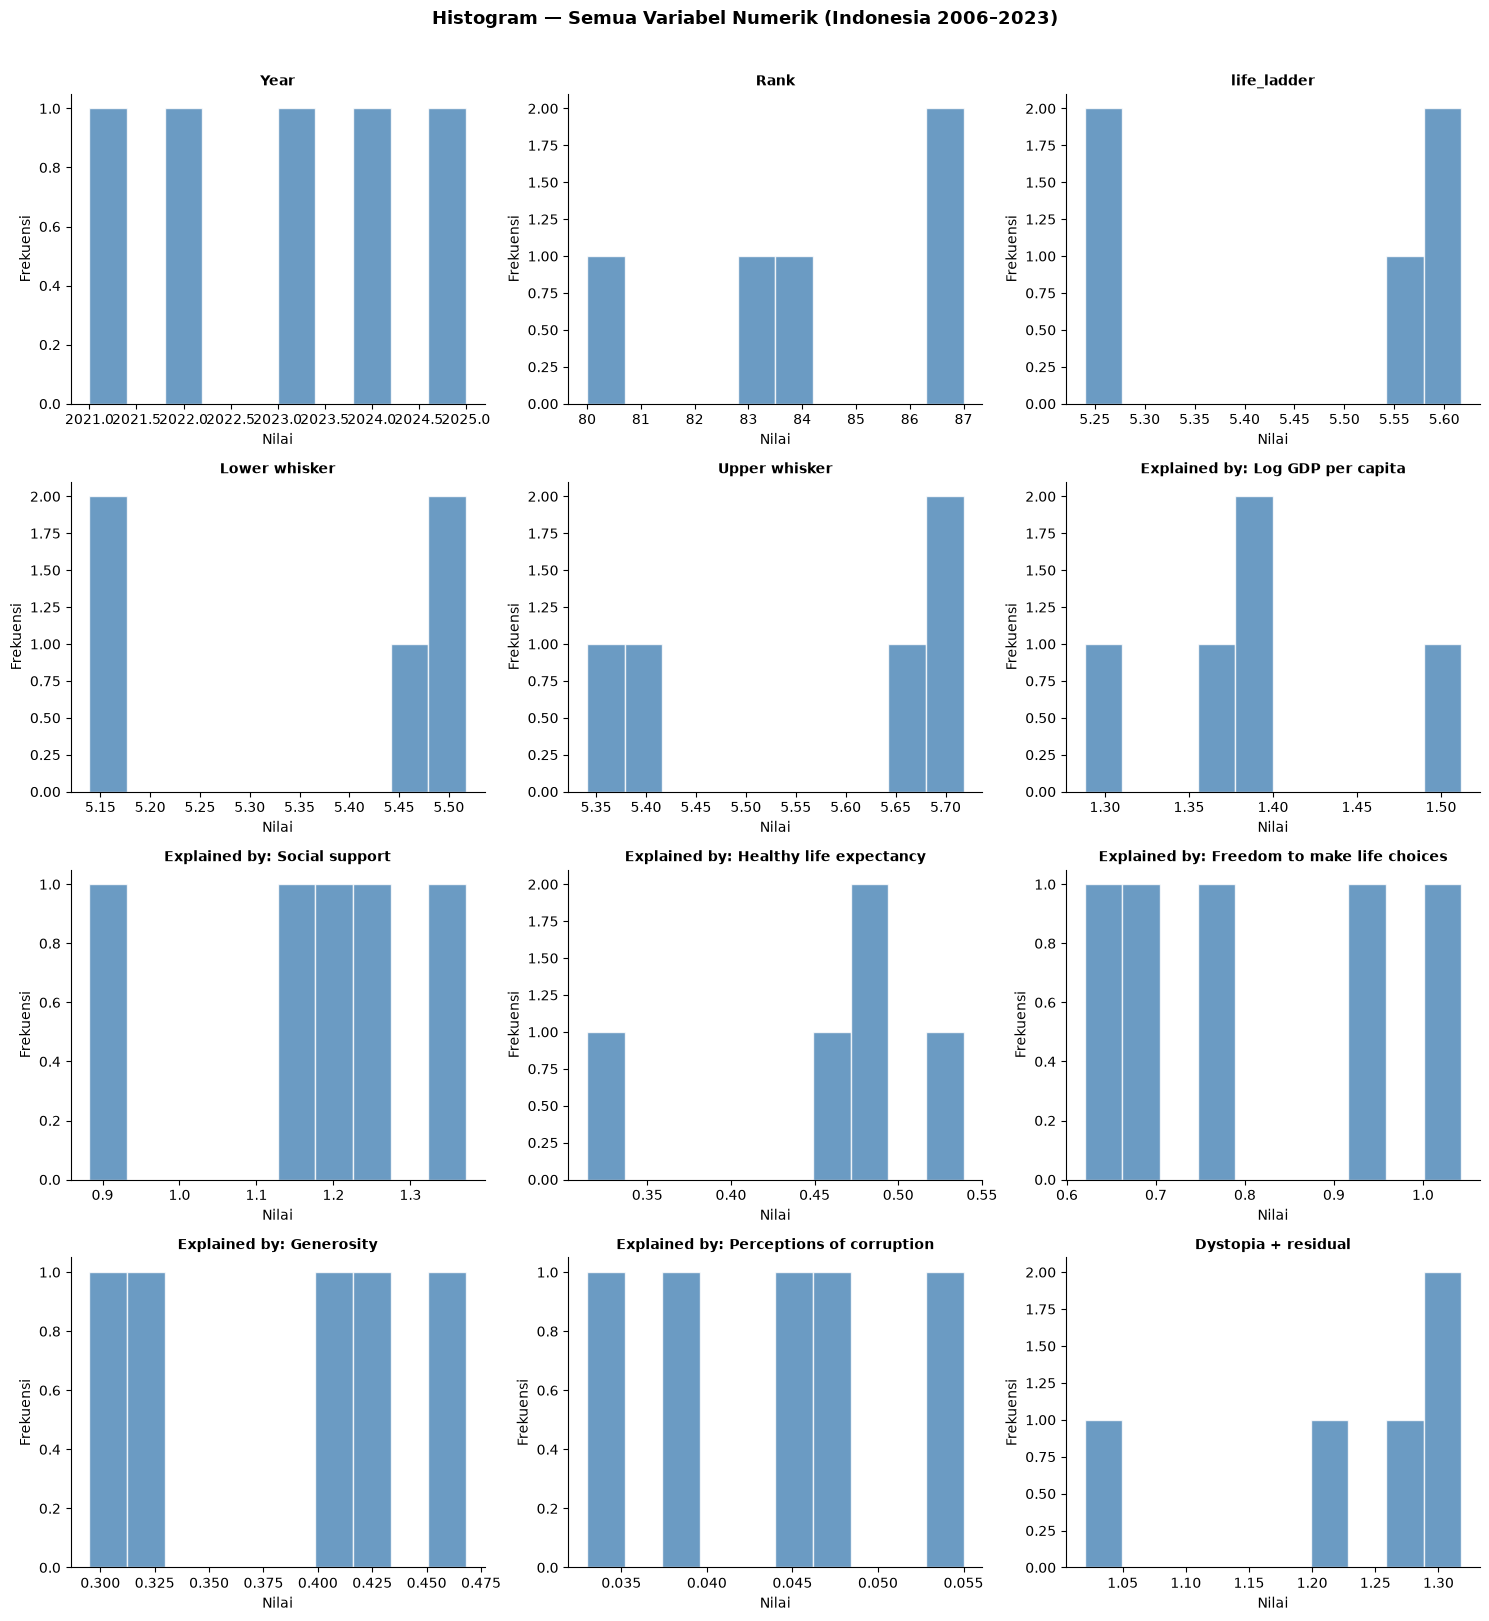

In [34]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2006–2023)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [35]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Year,0.0000,-1.2000
Rank,-0.5183,-0.7967
life_ladder,-0.5811,-3.1477
Lower whisker,-0.5657,-3.2292
Upper whisker,-0.6033,-3.0284
Explained by: Log GDP per capita,0.8609,2.1766
Explained by: Social support,-1.0481,2.3328
Explained by: Healthy life expectancy,-1.4102,2.8280
Explained by: Freedom to make life choices,0.4449,-1.5987
Explained by: Generosity,-0.1406,-1.8848


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | | | |
| *(lainnya)* | | | |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

In [ ]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life Ladder', 'Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2006–2023', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

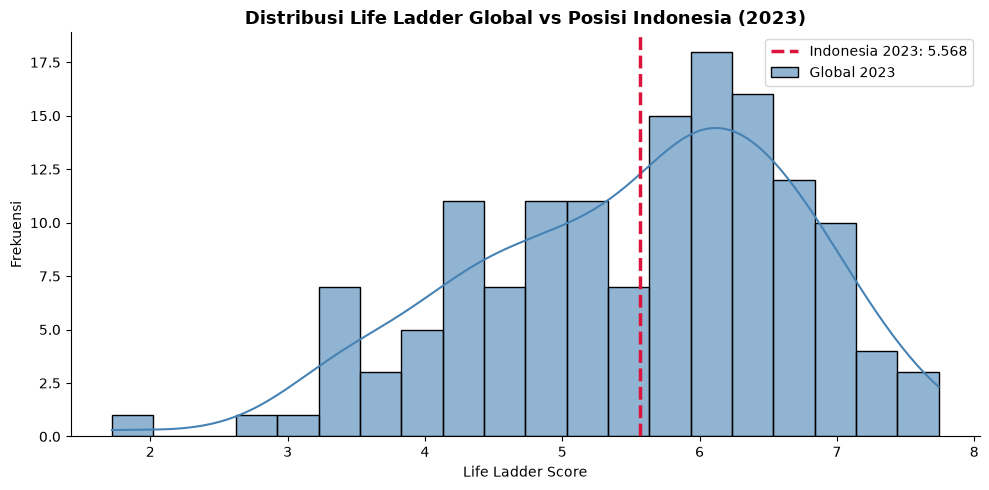

In [37]:
# e. Indonesia vs Global — Life Ladder 2023
global_2023 = df_whr[df_whr['Year'] == 2023]['life_ladder'].dropna()
idn_2023    = df_idn[df_idn['Year'] == 2023]['life_ladder']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2023, bins=20, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2023')

if len(idn_2023) > 0:
    ax.axvline(idn_2023.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2023: {idn_2023.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Jawaban Anda di sini...

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

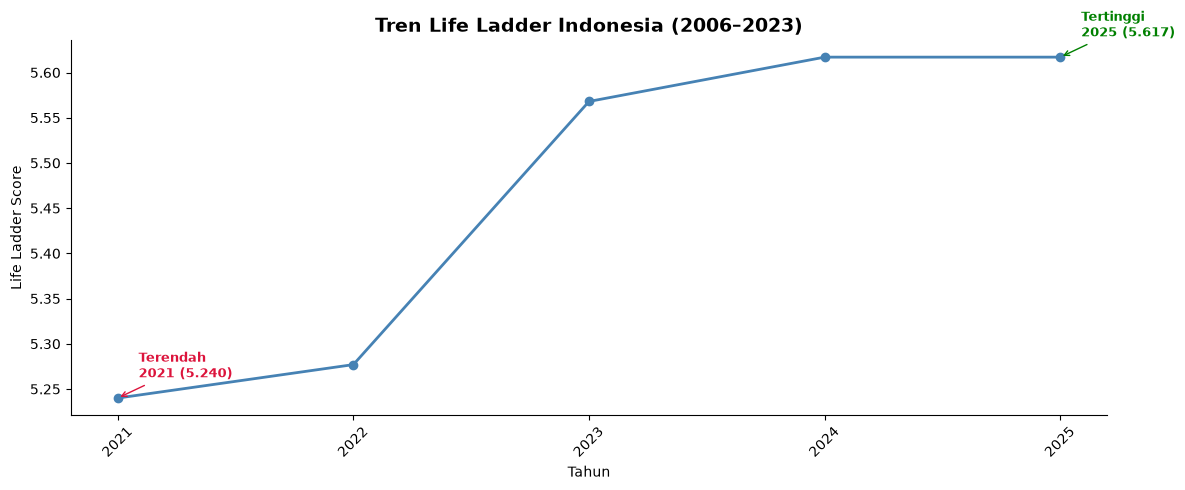

In [44]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_idn['Year'], df_idn['life_ladder'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn['life_ladder'].idxmax()
idx_min = df_idn['life_ladder'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df_idn.loc[idx, 'Year']} ({df_idn.loc[idx, 'life_ladder']:.3f})",
        xy=(df_idn.loc[idx, 'Year'], df_idn.loc[idx, 'life_ladder']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2006–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['Year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

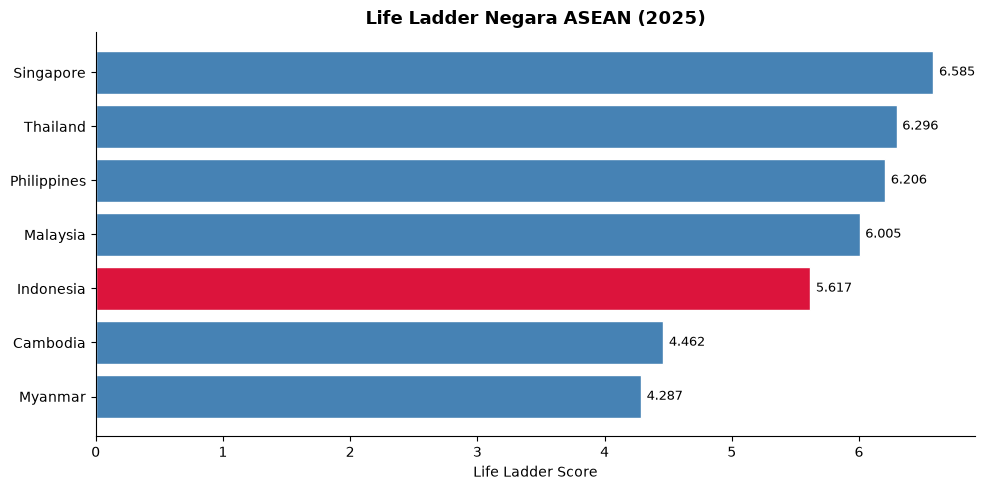

In [48]:
# b. Bar Chart — Life Ladder ASEAN 2023
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['Year'] == 2025)][['Country name', 'life_ladder']]\
             .sort_values('life_ladder', ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023['life_ladder'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout(); plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> Jawaban Anda di sini...

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

In [ ]:
# d. Heatmap — nilai variabel per tahun
heatmap_data = df_idn.set_index('ear')[numeric_cols]

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

KeyError: "None of ['year'] are in the columns"

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

In [ ]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Log GDP per capita',              'Life Ladder'),
    ('Social support',                  'Life Ladder'),
    ('Healthy life expectancy at birth', 'Life Ladder'),
    ('Perceptions of corruption',        'Life Ladder'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel:*

| Pasang Variabel | r | Interpretasi |
|---|---|---|
| Log GDP vs Life Ladder | | |
| Social support vs Life Ladder | | |
| Life expectancy vs Life Ladder | | |
| Corruption vs Life Ladder | | |

**c.** Correlation Heatmap semua variabel numerik.

In [ ]:
# c. Correlation Heatmap
corr = df_idn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2006–2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah ... dengan nilai r = ...*

> Jelaskan interpretasinya di sini...

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> Jawaban Anda di sini...

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...
4. **Insight 4:** ...
5. **Insight 5:** ...

**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [ ]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life Ladder']\
           .drop('Life Ladder').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

✏️ *Interpretasi 3 variabel teratas:*

> Jawaban Anda di sini...

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Dukung dengan data dan visualisasi di atas...

**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [ ]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
             .groupby('Country name')['Life Ladder']\
             .mean().sort_values(ascending=False)\
             .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* ...
2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* ...

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> ...

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> ...

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> ...

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> ...

> **Paragraf 5 — Rekomendasi & penutup:**  
> ...